In [2]:
from transformers import GPT2LMHeadModel
import matplotlib.pyplot as plt
%matplotlib inline

e:\workspace\pyscripts\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
model_hf = GPT2LMHeadModel.from_pretrained("gpt2")
sd_hf    = model_hf.state_dict()

for k, v in sd_hf.items():
    print(k, v.shape)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11896.00it/s]


transformer.wte.weight torch.Size([50257, 768])
transformer.wpe.weight torch.Size([1024, 768])
transformer.h.0.ln_1.weight torch.Size([768])
transformer.h.0.ln_1.bias torch.Size([768])
transformer.h.0.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.0.attn.c_attn.bias torch.Size([2304])
transformer.h.0.attn.c_proj.weight torch.Size([768, 768])
transformer.h.0.attn.c_proj.bias torch.Size([768])
transformer.h.0.ln_2.weight torch.Size([768])
transformer.h.0.ln_2.bias torch.Size([768])
transformer.h.0.mlp.c_fc.weight torch.Size([768, 3072])
transformer.h.0.mlp.c_fc.bias torch.Size([3072])
transformer.h.0.mlp.c_proj.weight torch.Size([3072, 768])
transformer.h.0.mlp.c_proj.bias torch.Size([768])
transformer.h.1.ln_1.weight torch.Size([768])
transformer.h.1.ln_1.bias torch.Size([768])
transformer.h.1.attn.c_attn.weight torch.Size([768, 2304])
transformer.h.1.attn.c_attn.bias torch.Size([2304])
transformer.h.1.attn.c_proj.weight torch.Size([768, 768])
transformer.h.1.attn.c_proj.bias 

In [4]:
sd_hf["transformer.wpe.weight"].shape # view(-1)[:20]

torch.Size([1024, 768])

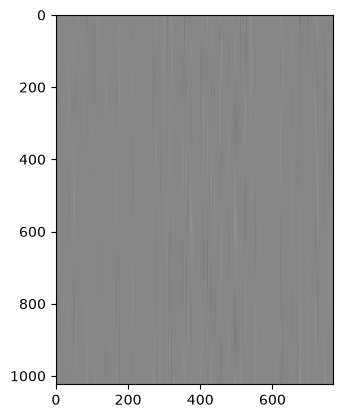

In [5]:
plt.imshow(sd_hf["transformer.wpe.weight"], cmap = "gray")

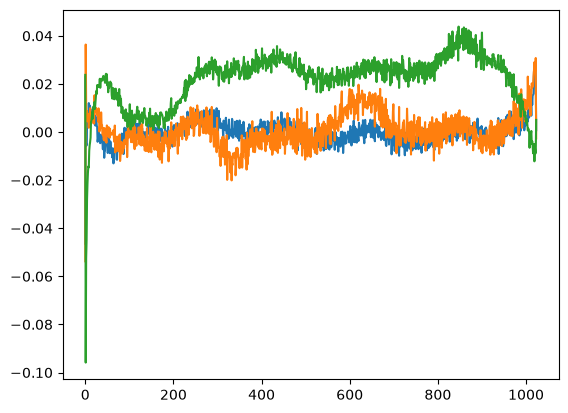

In [6]:
plt.plot(sd_hf["transformer.wpe.weight"][:, 150])
plt.plot(sd_hf["transformer.wpe.weight"][:, 200])
plt.plot(sd_hf["transformer.wpe.weight"][:, 250])

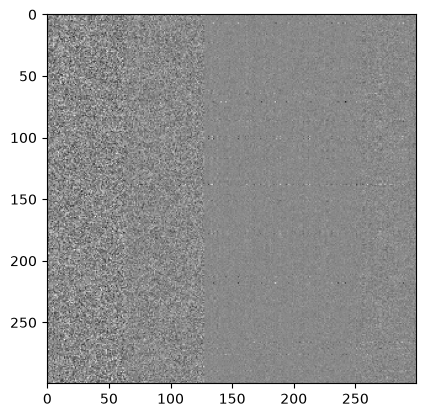

In [7]:
plt.imshow(sd_hf["transformer.h.1.attn.c_attn.weight"][:300, :300], cmap = "gray")

In [9]:
from transformers import pipeline, set_seed
generator = pipeline('text-generation', model = 'gpt2')
set_seed(42)
generator("The final answer of the life, the universe and everything is", max_length = 30, num_return_sequences = 5)

Loading weights: 100%|██████████| 148/148 [00:00<00:00, 11990.67it/s]
[transformers] Both `max_new_tokens` (=256) and `max_length`(=30) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


[{'generated_text': "The final answer of the life, the universe and everything is for you.\n\nIt is the ultimate human experience.\n\nThe one you remember is your mother.\n\nWe have seen that.\n\nThe other life you remember is the one you are born with right now.\n\nThe one you were born with right now is the one you will someday be.\n\nThe one you will someday die for.\n\nThe one you will someday live for.\n\nThe one you will someday be raised.\n\nThe one you will someday be a hero.\n\nThe one you will someday be a saint.\n\nThe one you will someday be a god.\n\nThe one you will someday be a god's son.\n\nThe one you will someday be a man's son.\n\nThe one you will someday be a man's son's son.\n\nThe one you will someday be the son of a noble man.\n\nThe one you will someday be that noble man's son.\n\nThe one you will someday be that noble man's son's son's son.\n\nThe one you will someday be that noble man's son's son's son's son.\n\nThe one you will someday be that noble man's son

In [1]:
with open('src/input.txt', 'r') as f:
    text = f.read()
data = text[:1000]
print(data[:100])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You


In [2]:
import tiktoken
enc = tiktoken.get_encoding('gpt2')
tokens = enc.encode(data)
print(tokens[:24])

[5962, 22307, 25, 198, 8421, 356, 5120, 597, 2252, 11, 3285, 502, 2740, 13, 198, 198, 3237, 25, 198, 5248, 461, 11, 2740, 13]


In [4]:
import torch
buf = torch.tensor(tokens[:24 + 1])
x = buf[:-1].view(4, 6)
y = buf[1: ].view(4, 6)
print(x)
print(y)

tensor([[ 5962, 22307,    25,   198,  8421,   356],
        [ 5120,   597,  2252,    11,  3285,   502],
        [ 2740,    13,   198,   198,  3237,    25],
        [  198,  5248,   461,    11,  2740,    13]])
tensor([[22307,    25,   198,  8421,   356,  5120],
        [  597,  2252,    11,  3285,   502,  2740],
        [   13,   198,   198,  3237,    25,   198],
        [ 5248,   461,    11,  2740,    13,   198]])
